In [1]:
import os, shutil, json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import MinMaxScaler
import joblib
import warnings
from collections import Counter
warnings.filterwarnings("ignore")

# create all dirs upfront
for d in ["/content/unified", "/content/raw", "/content/figures",
          "/content/checkpoints",
          "/content/processed_FD001", "/content/processed_FD002",
          "/content/processed_FD003", "/content/processed_FD004"]:
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FEATURE_COLS = [
    "op1","op2",
    "s2","s3","s4","s7","s8","s9",
    "s11","s12","s13","s14","s15","s17","s20","s21",
]
CLASS_NAMES = ["C0 healthy", "C1 early", "C2 advanced", "C3 imminent"]
NUM_CLASSES = 4
SEQ_LEN     = 30
INPUT_DIM   = 16

print(f"Device : {DEVICE}")
print("Directories created.")


Device : cuda
Directories created.


In [2]:
from google.colab import files

print("Upload ALL 18 files at once:")
print("  X_train_unified.npy, labels_train_unified.npy")
print("  test_FD001.txt, test_FD002.txt, test_FD003.txt, test_FD004.txt")
print("  RUL_FD001.txt,  RUL_FD002.txt,  RUL_FD003.txt,  RUL_FD004.txt")
print("  global_scaler_FD001.pkl ... global_scaler_FD004.pkl")
print("  engine_scalers_FD001.pkl ... engine_scalers_FD004.pkl")
uploaded = files.upload()
print(f"\nUploaded {len(uploaded)} files:")
for f in uploaded: print(f"  {f}")


Upload ALL 18 files at once:
  X_train_unified.npy, labels_train_unified.npy
  test_FD001.txt, test_FD002.txt, test_FD003.txt, test_FD004.txt
  RUL_FD001.txt,  RUL_FD002.txt,  RUL_FD003.txt,  RUL_FD004.txt
  global_scaler_FD001.pkl ... global_scaler_FD004.pkl
  engine_scalers_FD001.pkl ... engine_scalers_FD004.pkl


Saving engine_scalers_FD004.pkl to engine_scalers_FD004.pkl
Saving global_scaler_FD004.pkl to global_scaler_FD004.pkl
Saving engine_scalers_FD003.pkl to engine_scalers_FD003.pkl
Saving global_scaler_FD003.pkl to global_scaler_FD003.pkl
Saving engine_scalers_FD002.pkl to engine_scalers_FD002.pkl
Saving global_scaler_FD002.pkl to global_scaler_FD002.pkl
Saving engine_scalers_FD001.pkl to engine_scalers_FD001.pkl
Saving global_scaler_FD001.pkl to global_scaler_FD001.pkl
Saving test_FD003.txt to test_FD003.txt
Saving test_FD004.txt to test_FD004.txt
Saving RUL_FD001.txt to RUL_FD001.txt
Saving RUL_FD002.txt to RUL_FD002.txt
Saving RUL_FD003.txt to RUL_FD003.txt
Saving RUL_FD004.txt to RUL_FD004.txt
Saving test_FD001.txt to test_FD001.txt
Saving test_FD002.txt to test_FD002.txt

Uploaded 16 files:
  engine_scalers_FD004.pkl
  global_scaler_FD004.pkl
  engine_scalers_FD003.pkl
  global_scaler_FD003.pkl
  engine_scalers_FD002.pkl
  global_scaler_FD002.pkl
  engine_scalers_FD001.pkl
  global_s

In [3]:
# auto-route every uploaded file to the correct directory
import glob

routing = {
    "X_train_unified.npy"      : "/content/unified/X_train_unified.npy",
    "labels_train_unified.npy" : "/content/unified/labels_train_unified.npy",
}

for subset in ["FD001","FD002","FD003","FD004"]:
    routing[f"test_{subset}.txt"]          = f"/content/raw/test_{subset}.txt"
    routing[f"RUL_{subset}.txt"]           = f"/content/raw/RUL_{subset}.txt"
    routing[f"global_scaler_{subset}.pkl"] = f"/content/processed_{subset}/global_scaler_{subset}.pkl"
    routing[f"engine_scalers_{subset}.pkl"]= f"/content/processed_{subset}/engine_scalers_{subset}.pkl"

moved, missing = [], []
for fname, dst in routing.items():
    src = f"/content/{fname}"
    if os.path.exists(src):
        shutil.move(src, dst)
        moved.append(fname)
    else:
        missing.append(fname)

print(f"Moved  ({len(moved)}): {moved}")
print(f"Missing({len(missing)}): {missing}")

# verify key files
print("\nVerification:")
print(f"  unified     : {os.listdir('/content/unified')}")
print(f"  raw         : {os.listdir('/content/raw')}")
print(f"  processed_FD001: {os.listdir('/content/processed_FD001')}")


Moved  (16): ['test_FD001.txt', 'RUL_FD001.txt', 'global_scaler_FD001.pkl', 'engine_scalers_FD001.pkl', 'test_FD002.txt', 'RUL_FD002.txt', 'global_scaler_FD002.pkl', 'engine_scalers_FD002.pkl', 'test_FD003.txt', 'RUL_FD003.txt', 'global_scaler_FD003.pkl', 'engine_scalers_FD003.pkl', 'test_FD004.txt', 'RUL_FD004.txt', 'global_scaler_FD004.pkl', 'engine_scalers_FD004.pkl']
Missing(2): ['X_train_unified.npy', 'labels_train_unified.npy']

Verification:
  unified     : []
  raw         : ['test_FD004.txt', 'RUL_FD004.txt', 'test_FD001.txt', 'RUL_FD001.txt', 'test_FD002.txt', 'test_FD003.txt', 'RUL_FD002.txt', 'RUL_FD003.txt']
  processed_FD001: ['global_scaler_FD001.pkl', 'engine_scalers_FD001.pkl']


In [6]:
from google.colab import files

print("Upload these 4 files:")
print("  X_train_unified.npy, labels_train_unified.npy")
print("  X_balanced_FD001.npy, labels_balanced_FD001.npy")
uploaded = files.upload()

import shutil, os
for fname in ["X_train_unified.npy", "labels_train_unified.npy"]:
    if os.path.exists(f"/content/{fname}"):
        shutil.move(f"/content/{fname}", f"/content/unified/{fname}")
        print(f"Moved {fname}")

for fname in ["X_balanced_FD001.npy", "labels_balanced_FD001.npy"]:
    if os.path.exists(f"/content/{fname}"):
        shutil.move(f"/content/{fname}", f"/content/processed_FD001/{fname}")
        print(f"Moved {fname}")

print("Unified:", os.listdir("/content/unified"))

Upload these 4 files:
  X_train_unified.npy, labels_train_unified.npy
  X_balanced_FD001.npy, labels_balanced_FD001.npy


Saving labels_train_unified.npy to labels_train_unified.npy
Saving X_train_unified.npy to X_train_unified.npy
Saving labels_balanced_FD001.npy to labels_balanced_FD001.npy
Saving X_balanced_FD001.npy to X_balanced_FD001.npy
Moved X_train_unified.npy
Moved labels_train_unified.npy
Moved X_balanced_FD001.npy
Moved labels_balanced_FD001.npy
Unified: ['labels_train_unified.npy', 'X_train_unified.npy']


In [7]:
X_train = np.load("/content/unified/X_train_unified.npy")
y_train = np.load("/content/unified/labels_train_unified.npy")
X_fd001 = np.load("/content/processed_FD001/X_balanced_FD001.npy")
y_fd001 = np.load("/content/processed_FD001/labels_balanced_FD001.npy")

print(f"X_train  : {X_train.shape}")
print(f"y_train  : {y_train.shape}")
print(f"Class dist: {Counter(y_train.tolist())}")


X_train  : (122128, 30, 16)
y_train  : (122128,)
Class dist: Counter({3: 30652, 2: 30586, 0: 30472, 1: 30418})


In [8]:
class FaultDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE    = 128
train_dataset = FaultDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True, drop_last=True)
print(f"Train batches : {len(train_loader)}")

fd001_dataset = FaultDataset(X_fd001, y_fd001)
fd001_loader  = DataLoader(fd001_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


Train batches : 954


In [9]:
class FaultClassifier1DCNN(nn.Module):
    def __init__(self, input_dim, seq_len, num_classes):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(input_dim, 64,  kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64,        128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128,       256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(8),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv_block(x)
        return self.classifier(x)

def compute_val_f1(model, loader, device, average='macro'):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y_batch.numpy())
    model.train()
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    return float(f1_score(y_true, y_pred, average=average))

class ClassifierEarlyStopping:
    def __init__(self, model, val_loader, ckpt_path, patience=5, eval_interval=5, device=None, min_delta=1e-4):
        self.model = model; self.val_loader = val_loader; self.ckpt_path = Path(ckpt_path)
        self.patience = patience; self.eval_interval = eval_interval
        self.device = device or torch.device('cpu'); self.min_delta = min_delta
        self._best_f1 = -1.0; self._no_improve = 0
    def step(self, epoch, val_f1=None):
        if (epoch + 1) % self.eval_interval != 0: return False
        if val_f1 is None: val_f1 = compute_val_f1(self.model, self.val_loader, self.device)
        print(f'  [EarlyStopping] epoch {epoch + 1}: val_macro_f1={val_f1:.4f}   best={self._best_f1:.4f}')
        if val_f1 >= self._best_f1 + self.min_delta:
            self._best_f1 = val_f1; self._no_improve = 0
            self.ckpt_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(self.model.state_dict(), self.ckpt_path)
        else:
            self._no_improve += 1
            if self._no_improve >= self.patience: return True
        return False
    def restore_best(self):
        if self.ckpt_path.exists(): self.model.load_state_dict(torch.load(self.ckpt_path, map_location=self.device))

def finetune_fd001(model, fd001_loader, device, epochs=10, lr=1e-4, weight_decay=1e-4, ckpt_path=None):
    model.to(device)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    print(f'Fine-tuning on FD001 for {epochs} epochs (lr={lr}, BUG-014 fix) ...')
    for epoch in range(epochs):
        for x_batch, y_batch in fd001_loader:
            x_batch = x_batch.to(device); y_batch = y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
    print('Fine-tuning complete.')
    if ckpt_path is not None:
        Path(ckpt_path).parent.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), ckpt_path)

model = FaultClassifier1DCNN(INPUT_DIM, SEQ_LEN, NUM_CLASSES).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Parameters: 1,242,564


In [10]:
EPOCHS    = 80
LR        = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()
history   = {"train_loss": [], "train_acc": []}

stopper = ClassifierEarlyStopping(
    model=model,
    val_loader=fd001_loader,
    ckpt_path='/content/checkpoints/best_unified.pt',
    patience=5,
    eval_interval=5,
    device=DEVICE
)
print(f"Training unified 1D-CNN for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        logits  = model(x_batch)
        loss    = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        preds          = logits.argmax(dim=1)
        total_loss    += loss.item() * len(y_batch)
        total_correct += (preds == y_batch).sum().item()
        total_samples += len(y_batch)

    scheduler.step()
    avg_loss = total_loss / total_samples
    avg_acc  = total_correct / total_samples
    history["train_loss"].append(avg_loss)
    history["train_acc"].append(avg_acc)

    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1:>3}/{EPOCHS}  loss={avg_loss:.4f}  acc={avg_acc:.4f}")

    if stopper.step(epoch):
        break

stopper.restore_best()

finetune_fd001(
    model=model,
    fd001_loader=fd001_loader,
    device=DEVICE,
    epochs=10,
    lr=1e-4,
    ckpt_path='/content/checkpoints/best_unified_finetuned.pt'
)
print("Training complete.")


Training unified 1D-CNN for 80 epochs...
  [EarlyStopping] epoch 5: val_macro_f1=0.9722   best=-1.0000
  [EarlyStopping] epoch 10: val_macro_f1=0.9855   best=0.9722
  [EarlyStopping] epoch 15: val_macro_f1=0.9872   best=0.9855
  Epoch  20/80  loss=0.1096  acc=0.9578
  [EarlyStopping] epoch 20: val_macro_f1=0.9912   best=0.9872
  [EarlyStopping] epoch 25: val_macro_f1=0.9939   best=0.9912
  [EarlyStopping] epoch 30: val_macro_f1=0.9960   best=0.9939
  [EarlyStopping] epoch 35: val_macro_f1=0.9962   best=0.9960
  Epoch  40/80  loss=0.0456  acc=0.9835
  [EarlyStopping] epoch 40: val_macro_f1=0.9965   best=0.9962
  [EarlyStopping] epoch 45: val_macro_f1=0.9983   best=0.9965
  [EarlyStopping] epoch 50: val_macro_f1=0.9990   best=0.9983
  [EarlyStopping] epoch 55: val_macro_f1=0.9993   best=0.9990
  Epoch  60/80  loss=0.0099  acc=0.9967
  [EarlyStopping] epoch 60: val_macro_f1=0.9997   best=0.9993
  [EarlyStopping] epoch 65: val_macro_f1=0.9999   best=0.9997
  [EarlyStopping] epoch 70: val_m

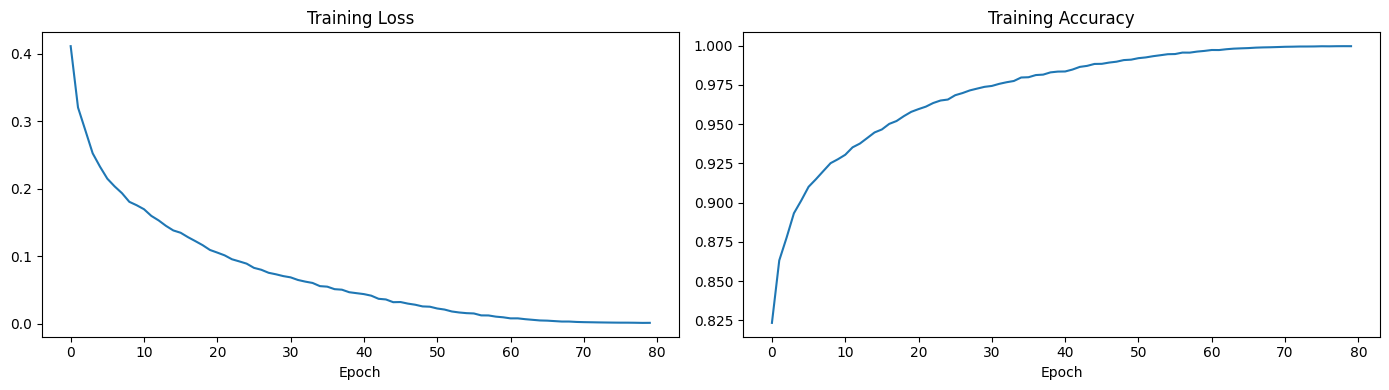

In [11]:
# training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history["train_loss"]); axes[0].set_title("Training Loss");   axes[0].set_xlabel("Epoch")
axes[1].plot(history["train_acc"]);  axes[1].set_title("Training Accuracy"); axes[1].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig("/content/figures/unified_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
COLUMNS      = (["engine_id","cycle"] + [f"op{i}" for i in range(1,4)]
                + [f"s{i}" for i in range(1,22)])
DROP_COLS    = ["s1","s5","s6","s10","s16","s18","s19","op3"]
GLOBAL_SCALE = ["s3"]
PER_ENGINE   = [f for f in FEATURE_COLS if f not in GLOBAL_SCALE]
CLASS_RUL_MIDPOINT = {0:125, 1:75, 2:30, 3:5}

def load_cmapss(path):
    df = pd.read_csv(path, sep=r"\s+", header=None)
    df = df.iloc[:, :len(COLUMNS)]
    df.columns = COLUMNS
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.drop(columns=DROP_COLS, errors="ignore")
    return df

def preprocess_test(df, global_scaler, engine_scalers):
    df = df.copy()
    df[GLOBAL_SCALE] = global_scaler.transform(df[GLOBAL_SCALE])
    scaled_parts = []
    for engine_id, group in df.groupby("engine_id"):
        group = group.copy()
        if engine_id in engine_scalers:
            group[PER_ENGINE] = engine_scalers[engine_id].transform(group[PER_ENGINE])
        else:
            group[PER_ENGINE] = MinMaxScaler().fit_transform(group[PER_ENGINE])
        scaled_parts.append(group)
    return pd.concat(scaled_parts).sort_values(["engine_id","cycle"]).reset_index(drop=True)

def get_last_window(df, window_size=30):
    X_test = []
    for engine_id, group in df.groupby("engine_id"):
        group = group.sort_values("cycle")
        feats = group[FEATURE_COLS].values
        if len(feats) >= window_size:
            window = feats[-window_size:]
        else:
            pad    = np.zeros((window_size - len(feats), feats.shape[1]))
            window = np.vstack([pad, feats])
        X_test.append(window)
    return np.array(X_test, dtype=np.float32)

def rul_to_class(rul):
    if rul > 100: return 0
    elif rul > 50: return 1
    elif rul > 10: return 2
    else: return 3

print("Test preprocessing helpers defined.")


Test preprocessing helpers defined.


In [13]:
results = {}
model.eval()

for subset in ["FD001","FD002","FD003","FD004"]:
    print(f"\n{'='*50}  {subset}")

    g_scaler  = joblib.load(f"/content/processed_{subset}/global_scaler_{subset}.pkl")
    e_scalers = joblib.load(f"/content/processed_{subset}/engine_scalers_{subset}.pkl")

    test_raw  = load_cmapss(f"/content/raw/test_{subset}.txt")
    test_df   = preprocess_test(test_raw, g_scaler, e_scalers)
    rul_df    = pd.read_csv(f"/content/raw/RUL_{subset}.txt",
                             header=None, names=["RUL"])
    y_rul     = rul_df["RUL"].values
    y_test    = np.array([rul_to_class(r) for r in y_rul])

    X_test    = get_last_window(test_df)
    X_tensor  = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        preds = model(X_tensor).argmax(dim=1).cpu().numpy()

    acc  = accuracy_score(y_test, preds)
    f1   = f1_score(y_test, preds, average="weighted", zero_division=0)
    rmse = np.sqrt(np.mean((
        np.array([CLASS_RUL_MIDPOINT[c] for c in preds]) - y_rul
    )**2))

    c3_mask   = y_test == 3
    c3_recall = (preds[c3_mask] == 3).mean() if c3_mask.sum() > 0 else 0.0

    print(f"Accuracy    : {acc:.4f}")
    print(f"F1 weighted : {f1:.4f}")
    print(f"RUL RMSE    : {rmse:.2f}")
    print(f"C3 recall   : {c3_recall:.2f}  (n={c3_mask.sum()})")
    print(classification_report(y_test, preds,
                                 target_names=CLASS_NAMES, zero_division=0))

    results[subset] = {
        "accuracy" : round(float(acc),  4),
        "f1"       : round(float(f1),   4),
        "rul_rmse" : round(float(rmse), 2),
        "c3_recall": round(float(c3_recall), 4),
        "y_true"   : y_test,
        "y_pred"   : preds,
    }



==================================================  FD001
Accuracy    : 0.5000
F1 weighted : 0.4915
RUL RMSE    : 33.85
C3 recall   : 0.86  (n=7)
              precision    recall  f1-score   support

  C0 healthy       0.51      0.70      0.59        33
    C1 early       0.40      0.29      0.34        34
 C2 advanced       0.85      0.42      0.56        26
 C3 imminent       0.35      0.86      0.50         7

    accuracy                           0.50       100
   macro avg       0.53      0.57      0.50       100
weighted avg       0.55      0.50      0.49       100


==================================================  FD002
Accuracy    : 0.4903
F1 weighted : 0.4716
RUL RMSE    : 50.22
C3 recall   : 0.32  (n=22)
              precision    recall  f1-score   support

  C0 healthy       0.77      0.36      0.49        92
    C1 early       0.39      0.33      0.36        79
 C2 advanced       0.44      0.92      0.59        66
 C3 imminent       0.78      0.32      0.45        22

In [14]:
print("\nUNIFIED CLASSIFIER — CROSS DATASET SUMMARY")
print("=" * 62)
print(f"{'Subset':<8} {'Accuracy':>10} {'F1':>8} {'RMSE':>8} {'C3 Recall':>10}")
print("-" * 62)
for subset, res in results.items():
    print(f"{subset:<8} {res['accuracy']:>10.4f} {res['f1']:>8.4f} "
          f"{res['rul_rmse']:>8.2f} {res['c3_recall']:>10.4f}")
print("=" * 62)



UNIFIED CLASSIFIER — CROSS DATASET SUMMARY
Subset     Accuracy       F1     RMSE  C3 Recall
--------------------------------------------------------------
FD001        0.5000   0.4915    33.85     0.8571
FD002        0.4903   0.4716    50.22     0.3182
FD003        0.3900   0.3665    49.30     0.5000
FD004        0.4677   0.4560    56.57     0.4286


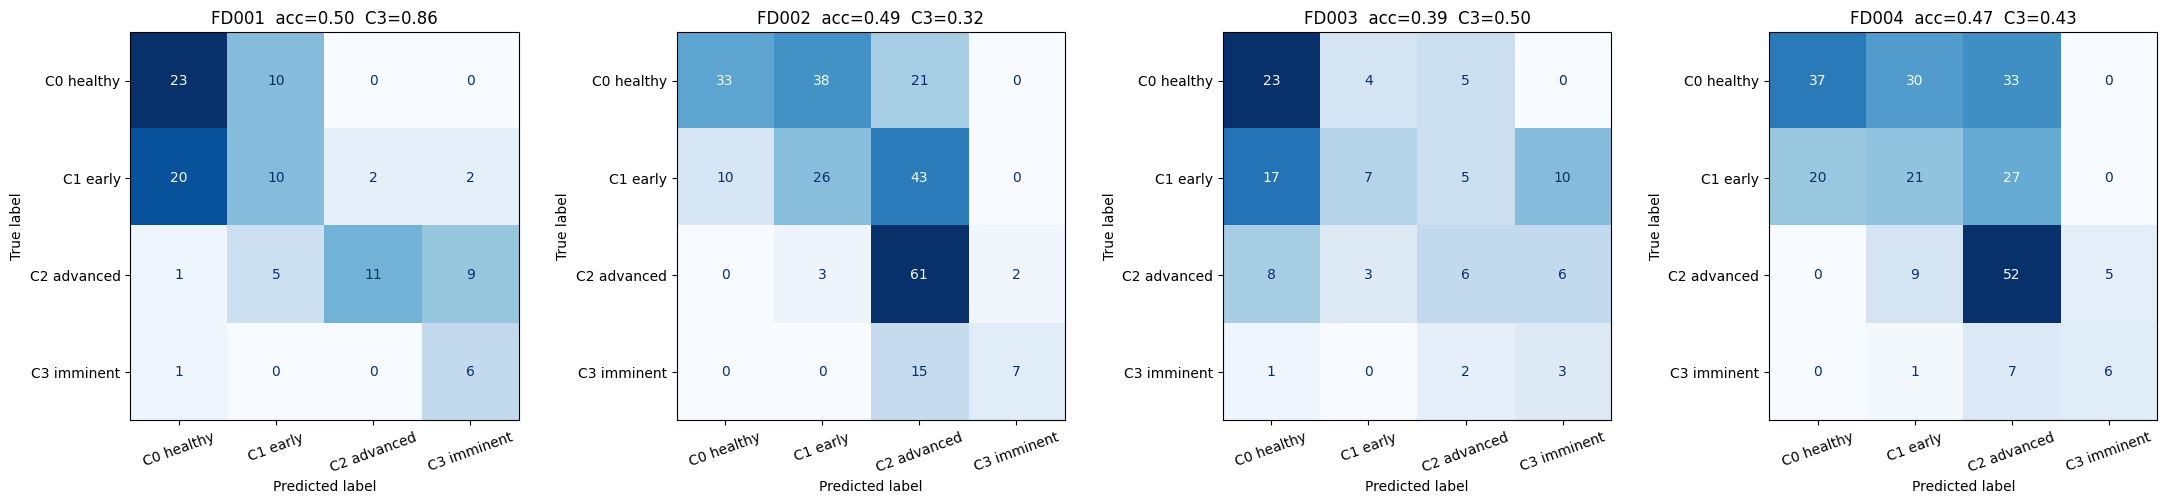

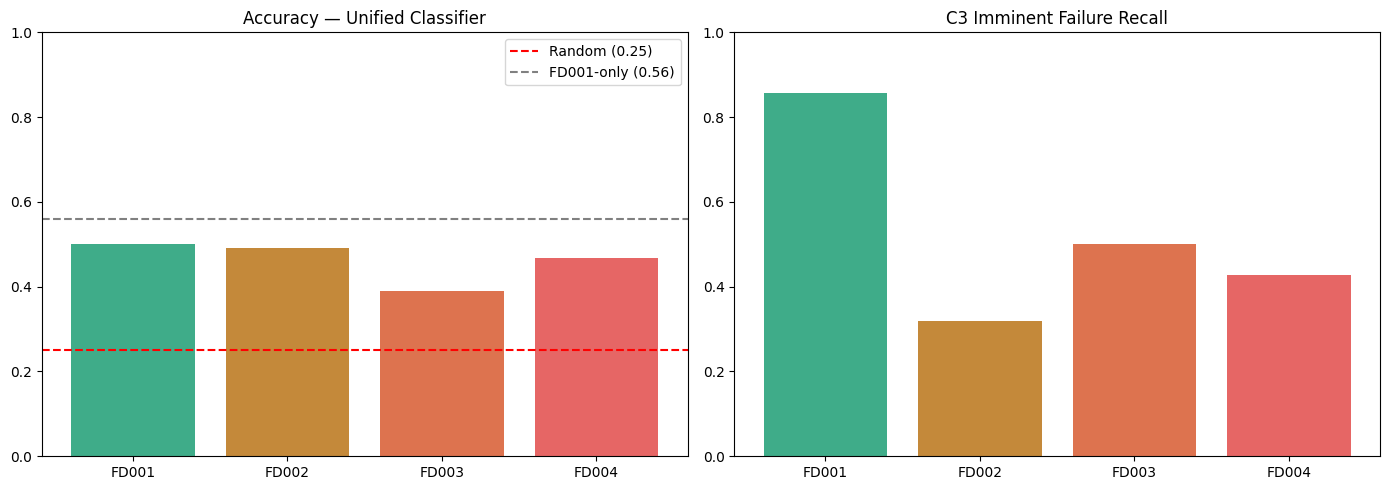

In [15]:
# confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (subset, res) in zip(axes, results.items()):
    cm   = confusion_matrix(res["y_true"], res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{subset}  acc={res['accuracy']:.2f}  C3={res['c3_recall']:.2f}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("/content/figures/unified_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# accuracy + C3 recall bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
subsets = list(results.keys())
colors  = ["#1D9E75","#BA7517","#D85A30","#E24B4A"]

axes[0].bar(subsets, [results[s]["accuracy"]  for s in subsets], color=colors, alpha=0.85)
axes[0].axhline(0.25, color="red",  linestyle="--", label="Random (0.25)")
axes[0].axhline(0.56, color="gray", linestyle="--", label="FD001-only (0.56)")
axes[0].set_title("Accuracy — Unified Classifier"); axes[0].set_ylim(0, 1); axes[0].legend()

axes[1].bar(subsets, [results[s]["c3_recall"] for s in subsets], color=colors, alpha=0.85)
axes[1].set_title("C3 Imminent Failure Recall"); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("/content/figures/unified_accuracy_c3recall.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
torch.save(model.state_dict(), "/content/checkpoints/unified_classifier_1dcnn.pt")

save_results = {s: {k:v for k,v in r.items() if k not in ["y_true","y_pred"]}
                for s, r in results.items()}
with open("/content/unified/phase13_results.json", "w") as f:
    json.dump(save_results, f, indent=2)

print("Saved model and results.")
print("\nStarting downloads...")

shutil.make_archive("/content/phase13_figures",     "zip", "/content/figures")
shutil.make_archive("/content/phase13_checkpoints", "zip", "/content/checkpoints")

files.download("/content/phase13_figures.zip")
files.download("/content/phase13_checkpoints.zip")
files.download("/content/unified/phase13_results.json")
print("Downloads started.")


Saved model and results.

Starting downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started.
